# <span style="color:purple; font-weight:bold; text-decoration:underline;"> East Asia & North Pacific Region Map

### <span style="color:purple"> Imports

In [1]:
import xarray as xr
from matplotlib import pyplot as plt
from cartopy import crs as ccrs, feature as cfeature
from cartopy.io import shapereader
import shapely.geometry as sgeom

### <span style="color:purple"> Region mask and lat/lon files

In [2]:
NPAC_mask = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/NPAC/NPAC_mask.nc')
lat = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/dimension_files/model_dims/lat.nc')
lon = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/dimension_files/model_dims/lon.nc')

### <span style="color:purple"> Plotting East Asian emission regions and NPAC

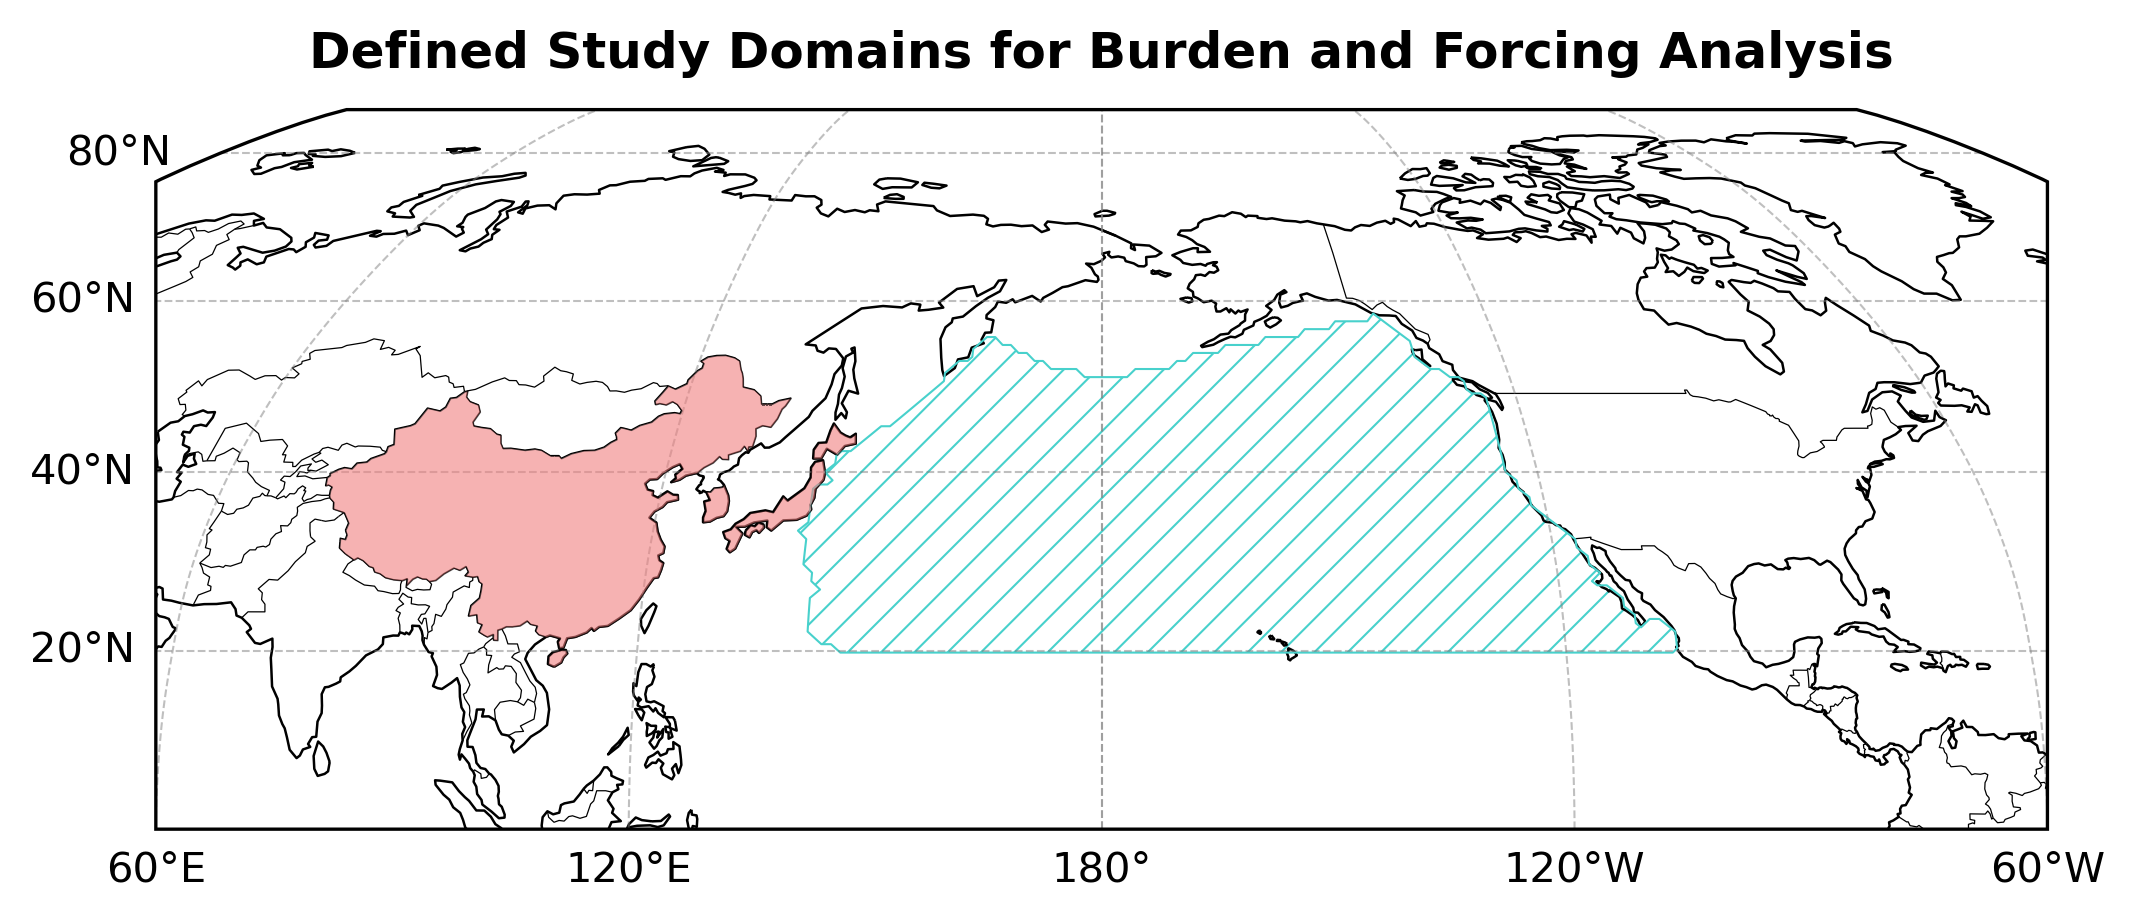

In [7]:
# --- Create figure and Robinson projection centered at 180° ---

fig, ax = plt.subplots(1, 1, figsize=(7.0, 4.0), dpi=300, subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, 
constrained_layout=True)

# --- Set geographic extent (min_lon, max_lon, min_lat, max_lat) ---
ax.set_extent([60, 300, 0, 90], crs=ccrs.PlateCarree())

# --- Style hatching ---
plt.rcParams['hatch.color'] = 'mediumturquoise'
plt.rcParams['hatch.linewidth'] = 0.5

# --- Plot mask and coastlines ---
m1 = ax.contour(lon, lat, NPAC_mask, transform=ccrs.PlateCarree(), colors='mediumturquoise', levels=[0.5], linewidths=0.5)
m2 = ax.contourf(lon, lat, NPAC_mask, transform=ccrs.PlateCarree(), colors='none', hatches=['///'], levels=[0.5, 1.5])

ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# --- Highlight specific countries ---
shpfilename = shapereader.natural_earth(resolution='110m', category='cultural', name='admin_0_countries')
reader = shapereader.Reader(shpfilename)
highlight_countries = ['China', 'Japan', 'South Korea']

for country in reader.records():
    if country.attributes['NAME'] in highlight_countries:
        geom = country.geometry
        ax.add_geometries([geom], crs=ccrs.PlateCarree(), facecolor='lightcoral', edgecolor='black', linewidth=0.3, alpha=0.6, zorder=5)

# --- Gridlines with labels ---
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5,
                  linewidth=0.5, color='gray')
gl.top_labels = False
gl.right_labels = False

# --- Title and layout ---
ax.set_title('Defined Study Domains for Burden and Forcing Analysis', pad=10, weight='bold')
plt.show()